# Plot pcFVA Results

In [1]:
from pathlib import Path
from itertools import chain
import textwrap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec
from rbc_gem_utils import read_cobra_model

In [2]:
model_id = "RBC3P_expanded"
dataset_name = "RBComics_G6PD"
data_path = Path("../../../../data/analysis/OVERLAY").resolve()
root_path = Path("../../../..").resolve()
results_path = root_path / "data" / "processed" / model_id / "OVERLAY"
pcmodel_dirpath = data_path / model_id
dataset_path = results_path / dataset_name
dataset_models_dirpath = dataset_path / "pcmodels"
pcfva_results_dirpath = dataset_path / "pcFVA"
corr_results_dirpath = dataset_path / "correlations"
df_pcfva_all_filename = pcfva_results_dirpath / f"{model_id}_PC_FVAresults_ALL.tsv"
model_filename = pcmodel_dirpath / f"{model_id}.xml"
pcmodel_filename = pcmodel_dirpath / f"{model_id}_PC.xml"
correlations2_dirpath = dataset_path / "correlations2"
flux_plots_path = dataset_path / "flux_plots"

print(results_path)
print(pcmodel_dirpath)
print(dataset_path)
print(dataset_models_dirpath)
print(pcfva_results_dirpath)
print(corr_results_dirpath)
print(df_pcfva_all_filename)
print(model_filename)
print(pcmodel_filename)
print(correlations2_dirpath)
print(flux_plots_path)

D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcmodels
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\pcFVA\RBC3P_expanded_PC_FVAresults_ALL.tsv
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded.xml
D:\Projects\RBC-GEM-akey7\data\analysis\OVERLAY\RBC3P_expanded\RBC3P_expanded_PC.xml
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\correlations2
D:\Projects\RBC-GEM-akey7\data\processed\RBC3P_expanded\OVERLAY\RBComics_G6PD\flux_plots


In [3]:
df_flux_abundance_correlation_filename = (
    correlations2_dirpath / "df_flux_abundance_correlation.csv"
)
df_flux_abundance_correlation = pd.read_csv(df_flux_abundance_correlation_filename)
df_flux_abundance_correlation

,Unnamed: 0,reactions,rho,raw_p_value,adj_p_value,neg_log10_adj_p_value,abundance_dependence,category
0,0,ADA,-0.069060,3.135064e-03,4.068913e-03,2.390522,Independent,Nucleotide metabolism
1,1,ADEt,-0.078595,7.702784e-04,1.021456e-03,2.990780,Independent,Transport reactions
2,2,ADK1,-0.096827,3.372097e-05,4.783672e-05,4.320239,Independent,Nucleotide metabolism
3,3,ADNK1,0.238054,5.734865e-25,1.249381e-24,23.903305,Independent,Nucleotide metabolism
4,4,ADNt,0.511792,1.361003e-122,4.151060e-122,121.381841,Correlated,Transport reactions
...,...,...,...,...,...,...,...,...
56,56,SPODM,0.058384,1.253744e-02,1.560783e-02,1.806657,Independent,Reactive species
57,57,TALA,0.083149,3.725993e-04,5.165582e-04,3.286881,Independent,Carbohydrate metabolism
58,58,TKT1,0.208445,2.155061e-19,4.108084e-19,18.386361,Independent,Carbohydrate metabolism
59,59,TKT2,0.208445,2.155061e-19,4.108084e-19,18.386361,Independent,Carbohydrate metabolism


In [4]:
def plot_correlations(
    df, vertical_lines, ax=None, histx=True, histy=True, colorbar=True, **kwargs
):
    # Define figure if no axes provided.
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.25)
    if ax is None:
        _, ax = plt.subplots(
            nrows=1,
            ncols=1,
            figsize=(
                scatter_inch + (hist_inch + hist_pad if histy else 0),
                scatter_inch + (hist_inch + hist_pad if histx else 0),
            ),
        )
    xy = {"x": "rho", "y": "neg_log10_adj_p_value"}
    limits = {
        "x": (kwargs.get("xmin", -1.0), kwargs.get("xmax", 1.0)),
        "y": (kwargs.get("ymin", 0.0), kwargs.get("ymax", df[xy["y"]].max())),
    }
    pads = {
        axis: kwargs.get(f"{axis}pad", (limits[axis][1] - limits[axis][0]) / 2 / 20)
        for axis in list(xy)
    }
    cmap = kwargs.get("cmap", "viridis")
    zorder = kwargs.get("zorder", 2)
    edgecolor = kwargs.get("edgecolor", "black")
    edgewidth = kwargs.get("edgewidth", 0.5)
    scatter = ax.scatter(
        xy["x"],
        xy["y"],
        data=df,
        c=kwargs.get("c", xy["y"]),
        s=kwargs.get("s", 40),
        alpha=0.5,
        zorder=zorder,
        edgecolor=edgecolor,
        linewidth=edgewidth,
        cmap=mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap,
        norm=mpl.colors.Normalize(
            vmin=limits["y"][0] - pads["y"], vmax=limits["y"][1] + pads["y"]
        ),
    )
    ax.set_xlabel(r"Spearman Correlation $(\rho)$", fontdict={"size": "xx-large"})
    ax.set_ylabel("-log$_{10}$(adj p-value)", fontdict={"size": "xx-large"})
    ax.set_xlim((limits["x"][0] - pads["x"], limits["x"][1] + pads["x"]))
    ax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))

    major_ticks = {axis: kwargs.get(f"{axis}tick_major") for axis in list(xy)}
    minor_ticks = {
        axis: kwargs.get(
            f"{axis}tick_minor",
            major_ticks[axis] / 2 if major_ticks[axis] is not None else None,
        )
        for axis in list(xy)
    }
    for axis in list(xy):
        if major_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_major_locator(
                mpl.ticker.MultipleLocator(major_ticks[axis])
            )
        if minor_ticks[axis] is not None:
            getattr(ax, f"{axis}axis").set_minor_locator(
                mpl.ticker.MultipleLocator(minor_ticks[axis])
            )
        ax.tick_params(axis=axis, labelsize="large")

    if vertical_lines:
        for lineval, (lineprops, textprops) in vertical_lines.items():
            if lineprops:
                ax.vlines(
                    x=lineval,
                    ymin=limits["y"][0] - pads["y"],
                    ymax=limits["y"][1] + pads["y"],
                    **lineprops,
                )
            if textprops:
                ax.text(x=lineval + pads["x"] / 2, transform=ax.transData, **textprops)

    if kwargs.get("grid", False):
        ax.grid(True, **dict(which="both", alpha=0.75))

    if colorbar:
        cax = ax.inset_axes(
            [
                limits["x"][0] - pads["x"],  # lower left corner xpos
                limits["y"][0] - pads["y"],  # lower left corner ypos
                pads["x"],  # width of colorbar
                limits["y"][1]
                + pads["y"]
                + pads[
                    "y"
                ],  # height of colorbar, need extra ypad to make up for lowering ypos
            ],
            transform=ax.transData,
        )
        cbar = ax.get_figure().colorbar(scatter, cax=cax)
        cax.set_ylim((limits["y"][0] - pads["y"], limits["y"][1] + pads["y"]))
        cax.set_xticks([])
        cax.set_yticks([])

    ax_histx = None
    ax_histy = None
    if histx or histy:
        divider = make_axes_locatable(ax)
        # Histogram axes
        ax_histx = (
            divider.append_axes("top", hist_inch, pad=hist_pad, sharex=ax)
            if histx
            else None
        )
        ax_histy = (
            divider.append_axes("right", hist_inch, pad=hist_pad, sharey=ax)
            if histy
            else None
        )

        for axis, ax_hist in zip(list(xy), [ax_histx, ax_histy]):
            if ax_hist is None:
                continue
            binwidth = kwargs.get(
                f"{axis}binwidth",
                (
                    minor_ticks[axis]
                    if minor_ticks[axis] is not None
                    else major_ticks[axis]
                ),
            )
            counts, bins, patches = ax_hist.hist(
                df[xy[axis]],
                bins=np.arange(limits[axis][0], limits[axis][1] + binwidth, binwidth),
                orientation="vertical" if axis == "x" else "horizontal",
                zorder=zorder,
                edgecolor=edgecolor,
                linewidth=edgewidth,
            )
            other = "y" if axis == "x" else "x"
            ax_hist.tick_params(
                axis=axis, **{f"label{'bottom' if axis == 'x' else 'left'}": False}
            )
            ax_hist.tick_params(axis=other, labelsize="large")
            getattr(ax_hist, f"set_{other}label")("Frequency", fontsize="large")

            tick_major_int = kwargs.get(f"hist{axis}_{other}tick_major")
            if tick_major_int is not None:
                getattr(ax_hist, f"{other}axis").set_major_locator(
                    mpl.ticker.MultipleLocator(tick_major_int)
                )
                getattr(ax_hist, f"{other}axis").set_minor_locator(
                    mpl.ticker.MultipleLocator(tick_major_int / 2)
                )
            getattr(ax_hist, f"set_{other}lim")((0, max(counts) * 1.1))
            if kwargs.get("grid", False):
                ax_hist.grid(True, **dict(which="both", alpha=0.75))

            if vertical_lines and (axis == "x" and ax_hist is not None):
                for lineval, (lineprops, _) in vertical_lines.items():
                    if lineprops:
                        ax_hist.vlines(
                            x=lineval, ymin=0.0, ymax=max(counts) * 1.1, **lineprops
                        )

    return ax, ax_histx, ax_histy

In [5]:
def make_flux_abundance_u_plot(df, histx=True, histy=True, colorbar=True, **kwargs):
    scatter_inch = kwargs.get("scatter_inch", 5.0)
    hist_inch = kwargs.get("hist_inch", 1.0)
    hist_pad = kwargs.get("hist_pad", 0.5)
    nrows, ncols = (1, 1)
    expression_dep_rho_lb = 0.8
    expression_cor_rho_lb = 0.5
    ypos = 4
    ww = 11
    rotation = 90
    fontsize = "large"
    linewidth = 2
    vertical_lines = {
        expression_dep_rho_lb: (
            dict(color="black", linestyle="-", linewidth=linewidth),
            dict(
                y=ypos,
                s="\n".join(textwrap.wrap("Expression dependent", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
        expression_cor_rho_lb: (
            dict(color="xkcd:dark grey", linestyle="--", linewidth=linewidth),
            dict(
                y=ypos,
                s="\n".join(textwrap.wrap("Expression correlated", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
        0.0: (
            dict(),
            dict(
                y=ypos + 50.0,
                s="\n".join(textwrap.wrap("Expression independent", width=ww)),
                rotation=rotation,
                fontsize=fontsize,
            ),
        ),
    }
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(
            (scatter_inch + (hist_inch + hist_pad if histx else 0)) * ncols,
            (scatter_inch + (hist_inch + hist_pad if histy else 0)) * nrows,
        ),
    )
    ax_scatter, ax_histx, ax_histy = plot_correlations(
        df,
        ax=ax,
        histx=histx,
        histy=histy,
        colorbar=True,
        vertical_lines=vertical_lines,
        xbinwidth=0.1,
        ybinwidth=10,
        **kwargs,
    )
    # ax_scatter.set_title(
    #     f"Correlates between Flux and Abundance",
    #     fontsize="x-large",
    # )
    fig.suptitle("Correlates Between Flux and Abundance", fontsize=18)

In [6]:
make_flux_abundance_u_plot(df_flux_abundance_correlation)
correlates_flux_abundance_plot_filename = (
    flux_plots_path / "correlates_flux_abundance.svg"
)
plt.savefig(
    correlates_flux_abundance_plot_filename,
    dpi=300,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.5,
    format="svg",
)
plt.close()

### Donut charts of subsystems

Look at categories and subsystems here: [KEGG pathways](https://www.kegg.jp/kegg/pathway.html) Look at "category" in df_pathways.

In [7]:
df_flux_abundance_correlation["category"].unique()

array(['Nucleotide metabolism', 'Transport reactions',
       'Metabolism of cofactors and vitamins', 'Carbohydrate metabolism',
       'Reactive species', 'Metabolism of other amino acids'],
      dtype=object)

In [8]:
def map_categories_to_colors(categories):
    color_for_category = {
        "Nucleotide metabolism": "#332288",
        "Transport reactions": "#117733",
        "Metabolism of cofactors and vitamins": "#44AA99",
        "Carbohydrate metabolism": "#88CCEE",
        "Reactive species": "#999933",
        "Metabolism of other amino acids": "#DDCC77",
    }
    return [color_for_category[category] for category in categories]

In [9]:
def make_subsystem_breakdown_by_abundance_dependence(
    df, abundance_dependence, figsize=(8, 8), title_y=1.2, center_title=None
):
    color_for_category = {
        "Nucleotide metabolism": "#332288",
        "Transport reactions": "#117733",
        "Metabolism of cofactors and vitamins": "#44AA99",
        "Carbohydrate metabolism": "#88CCEE",
        "Reactive species": "#999933",
        "Metabolism of other amino acids": "#DDCC77",
    }
    ring_series = df[df["abundance_dependence"] == abundance_dependence]["category"]
    ring_series = ring_series.value_counts()
    wedge_labels = [
        f"{value}: {'\n'.join(textwrap.wrap(index, width=20))}"
        for index, value in ring_series.items()
    ]
    wedge_colors = [color_for_category[category] for category, _ in ring_series.items()]
    # Create a figure and axis
    fig, ax = plt.subplots(figsize=figsize)
    wedges, texts = ax.pie(
        ring_series,
        labels=wedge_labels,
        startangle=90,
        wedgeprops={"edgecolor": "white"},
        colors=wedge_colors,
        labeldistance=1.2,
    )
    center_circle = plt.Circle((0, 0), 0.75, fc="white")
    ax.add_artist(center_circle)
    ax.set_aspect("equal")
    formatted_center_title = (
        f"{center_title}\n{sum(ring_series)}" if center_title else sum(ring_series)
    )
    ax.text(0, 0, formatted_center_title, ha="center", va="center", fontsize=12)
    plt.title(abundance_dependence, fontsize=14, y=title_y)

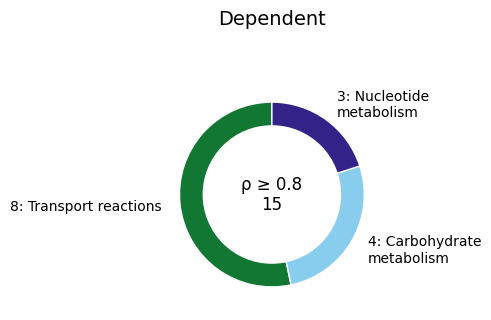

In [10]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation,
    abundance_dependence="Dependent",
    figsize=(3, 3),
    center_title="ρ ≥ 0.8",
)
dependent_reaction_categories_plot_filename = (
    flux_plots_path / "dependent_reaction_categories.svg"
)
plt.savefig(
    dependent_reaction_categories_plot_filename,
    dpi=300,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.5,
    format="svg",
)

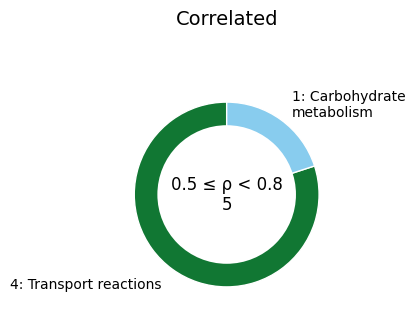

In [11]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation,
    abundance_dependence="Correlated",
    figsize=(3, 3),
    center_title="0.5 ≤ ρ < 0.8",
)
correlated_reaction_categories_plot_filename = (
    flux_plots_path / "correlated_reaction_categories.svg"
)
plt.savefig(
    correlated_reaction_categories_plot_filename,
    dpi=300,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.5,
    format="svg",
)

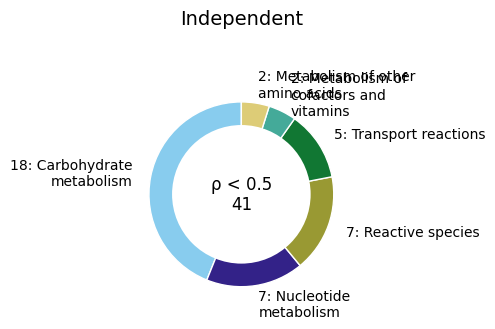

In [12]:
make_subsystem_breakdown_by_abundance_dependence(
    df_flux_abundance_correlation,
    abundance_dependence="Independent",
    figsize=(3, 3),
    center_title="ρ < 0.5",
)
independent_reaction_categories_plot_filename = (
    flux_plots_path / "independent_reaction_categories.svg"
)
plt.savefig(
    independent_reaction_categories_plot_filename,
    dpi=300,
    transparent=False,
    bbox_inches="tight",
    pad_inches=0.5,
    format="svg",
)

TODO: Make pathway map. Use Escher and instead of edge weights being fluxes, correlation coefficients.

### Gene reaction counts horizontal bar charts

In [13]:
df_gene_reaction_count_filename = correlations2_dirpath / "df_gene_reaction_count.csv"
df_gene_reaction_count = pd.read_csv(df_gene_reaction_count_filename)
df_gene_reaction_count

,abundance_dependence,genes,category,reactions
0,Correlated,BSG;EMB;SLC16A1;SLC16A7,Transport reactions,2
1,Correlated,SLC29A1,Transport reactions,2
2,Correlated,ENO1;ENO2;ENO3,Carbohydrate metabolism,1
3,Dependent,NT5C2,Nucleotide metabolism,2
4,Dependent,AMPD3,Nucleotide metabolism,1
5,Dependent,AQP1,Transport reactions,1
6,Dependent,AQP1;AQP3,Transport reactions,1
7,Dependent,AQP1;AQP3;RHAG;RHCE;RHD,Transport reactions,1
8,Dependent,AQP1;RHAG;RHCE;RHD,Transport reactions,1
9,Dependent,ATP2B1;ATP2B4,Transport reactions,1


In [14]:
def make_gene_reaction_count_plot(df, abundance_dependence, **kwargs):
    df1 = df[df["abundance_dependence"] == abundance_dependence][
        ["reactions", "genes", "category"]
    ]
    df1.set_index("genes", inplace=True)
    fig, ax = plt.subplots(nrows=1, ncols=1, **kwargs)
    ax.barh(
        df1.index, df1["reactions"], color=map_categories_to_colors(df1["category"])
    )

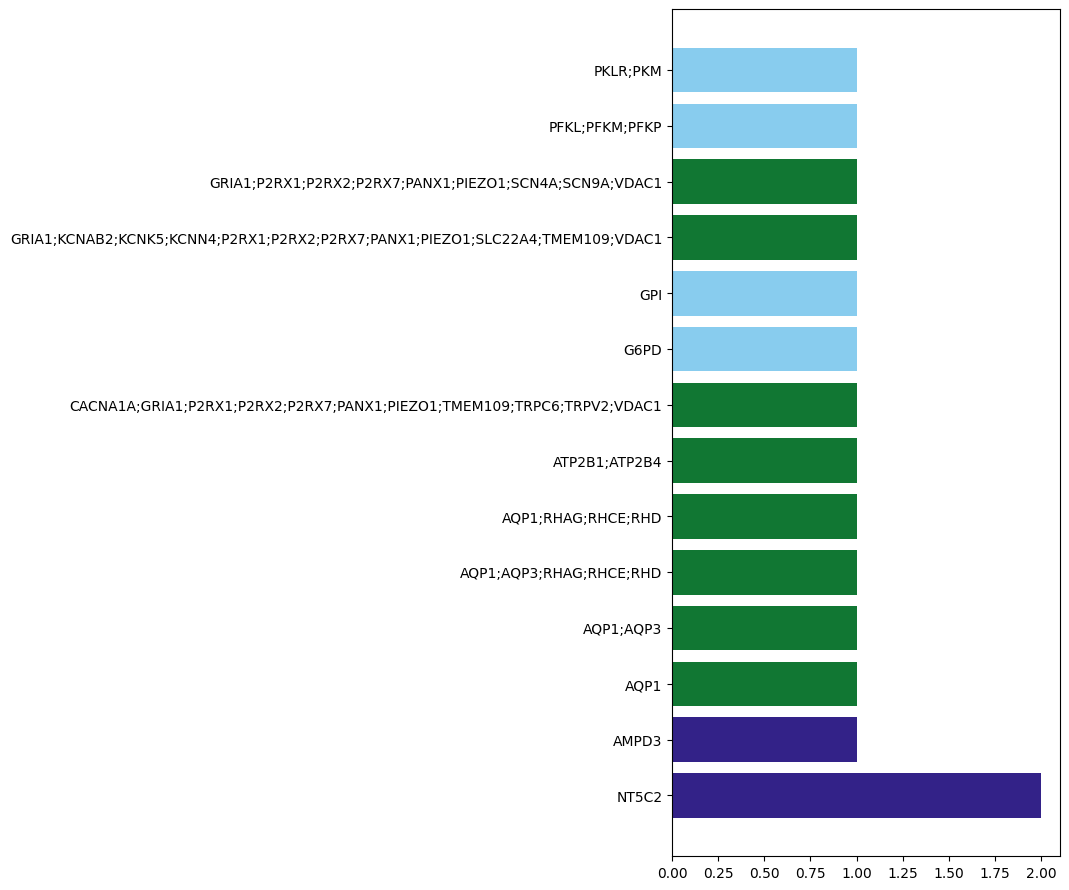

In [15]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Dependent", figsize=(5, 11))

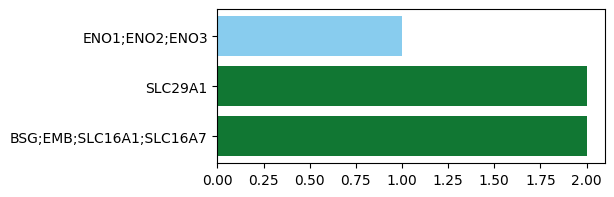

In [16]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Correlated", figsize=(5, 2))

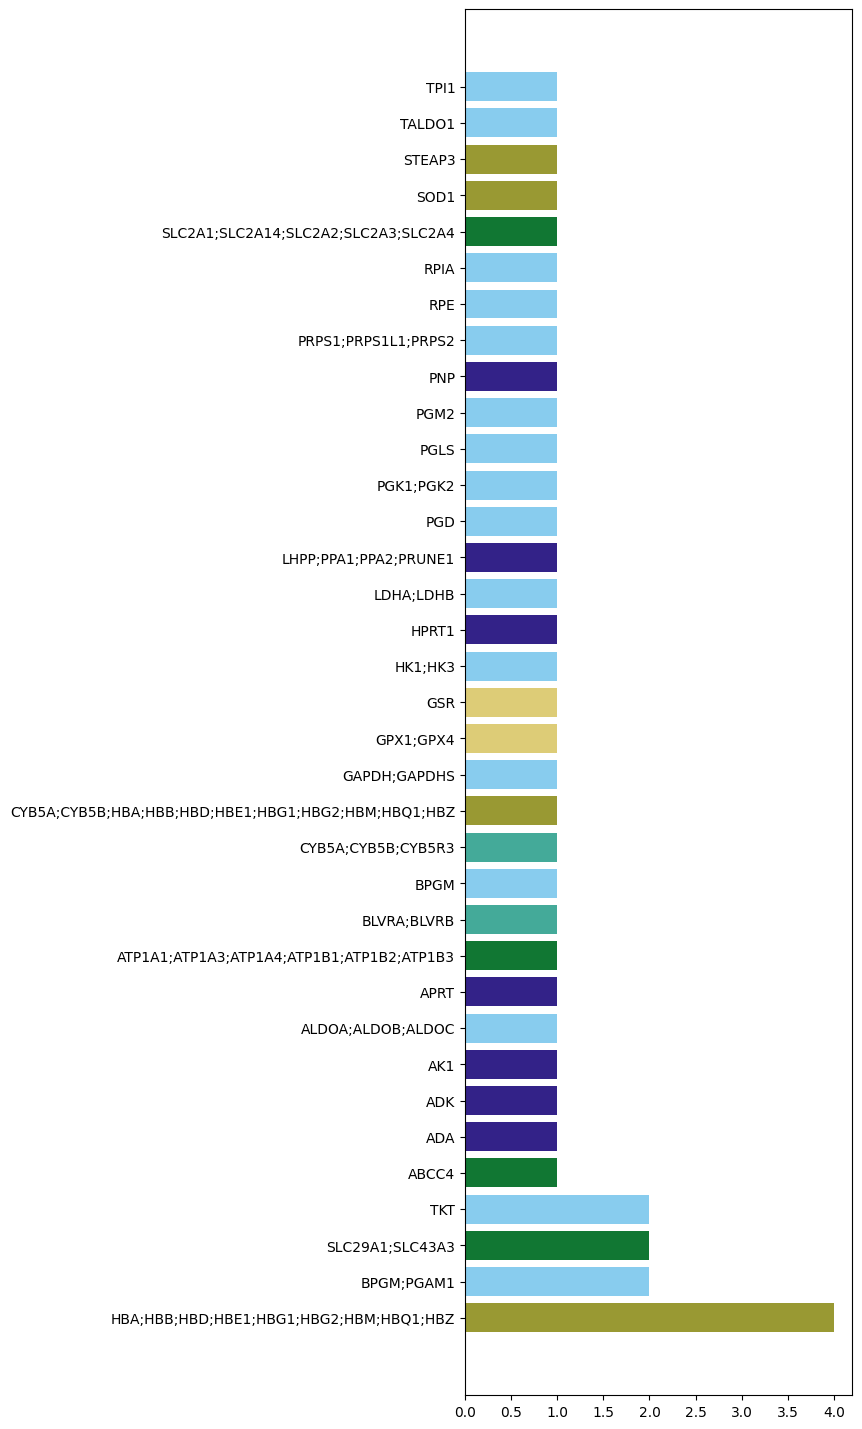

In [17]:
make_gene_reaction_count_plot(df_gene_reaction_count, "Independent", figsize=(5, 18))

### Plot solution space of by day, reaction, and G6PD_allele

In [18]:
df_pcfva_alleles_filename = correlations2_dirpath / "df_pcfva_alleles.csv"
df_pcfva_alleles = pd.read_csv(df_pcfva_alleles_filename)
df_pcfva_alleles.drop("sample_id", axis=1, inplace=True)
df_pcfva_alleles.set_index(
    ["G6PD_alleles", "day", "reactions", "optimum"], inplace=True
)
df_pcfva_alleles.sort_index(inplace=True)
df_pcfva_alleles

minimum   maximum     range
G6PD_alleles day reactions optimum                              
0            10  ADA       0.00     0.000000  0.279580  0.279580
                           0.00     0.000000  0.296455  0.296455
                           0.00     0.000000  0.236114  0.236114
                           0.00     0.000000  0.256270  0.256270
                           0.00     0.000000  0.264780  0.264780
...                                      ...       ...       ...
2            42  TPI       0.99     0.000000  0.001490  0.001490
                           0.99     0.000000  0.001435  0.001435
                           0.99     0.000000  0.001682  0.001682
                           0.99     0.004576  0.006829  0.002254
                           0.99     0.000000  0.001817  0.001817

[7780320 rows x 3 columns]

In [19]:
model = read_cobra_model(model_filename)
subsystem_reaction = {}
for reaction in model.reactions:
    subsystem = reaction.subsystem
    if subsystem in subsystem_reaction:
        subsystem_reaction[subsystem].append(reaction.id)
    else:
        subsystem_reaction[subsystem] = [reaction.id]
for subsystem, reaction_list in subsystem_reaction.items():
    joined_reaction_list = ", ".join(reaction_list)
    print(subsystem, len(reaction_list), joined_reaction_list)

Set parameter Username
Purine metabolism 9 ADA, ADK1, ADNK1, ADPT, AMPDA, HXPRT, NTDIMP, NTDAMP, PUNP5
Transport, extracellular 20 ADEt, ADNt, CA2t, CO2t, H2O2t, H2Ot, HYXNt, Ht, INSt, L_LACt2, NaKt, O2t, NAt, PIt, PYRt2, CAATPS1, GLC_Dt, Kt1, NH4t, BILRUBABCte
Glycolysis / Gluconeogenesis 13 DPGM, DPGase, ENO, FBA, HEX1, GAPD, LDH_L, PFK, PGI, PGK, PGM, PYK, TPI
Pentose phosphate pathway 10 G6PDH2, GND, PGL, PPM, PRPPS, RPE, RPI, TALA, TKT1, TKT2
Glutathione metabolism 2 GTHOy, GTHP
Nucleotide metabolism 2 PPA, NTPA
Hemoglobin binding and degradation 5 HB23DPGB, HBO2B1, HBO2B2, METHBCYTBR, OXYHBAOX
Nicotinate and nicotinamide metabolism 1 FCYTOB5OXR
Reactive species formation and detoxification 4 SPODM, FE2O2OX, FE3RD, FE2H2O2X
Pseudoreactions 24 EX_ca2_e, EX_co2_e, EX_glc__D_e, EX_h_e, EX_h2o_e, EX_h2o2_e, EX_ade_e, EX_hxan_e, EX_adn_e, EX_ins_e, EX_k_e, EX_lac__L_e, EX_na1_e, EX_nh4_e, EX_o2_e, EX_pi_e, EX_pyr_e, SK_hb4_23dpg_c, SK_oxyhb_c, SK_hb_hco2_c, SK_na1_c, SK_k_c, SK_ca2_c, 

In [20]:
flux_group_glycolysis = [
    ["HEX1", "PGI", "PFK", "FBA", "TPI"],
    ["GAPD", "PGK", "PGM", "ENO", "PYK"],
    ["LDH_L", "DPGM", "DPGase", "", "NaKt"],
]

flux_group_ppp = [
    ["G6PDH2", "PGL", "GND", "RPE", "RPI"],
    ["TKT1", "TALA", "TKT2", "PRPPS", "NaKt"],
]

flux_group_purine_metabolism = [
    ["ADPT", "ADK1", "ADNK1", "ADA", "AMPDA"],
    ["NTDIMP", "NTDAMP", "PUNP5", "HXPRT", "NaKt"],
]

In [21]:
def make_optimum_min_max_plot(
    day, reaction, optima=None, optimum_colors=None, save_filename=None, **kwargs
):
    optima = [0.0, 0.5, 0.9, 0.99] if not optima else optima
    optimum_colors = (
        ["#87CEEB", "#3399CC", "#004C99", "#000080"]
        if not optimum_colors
        else optimum_colors
    )
    fig, axs = plt.subplots(nrows=1, ncols=3, sharey=True, **kwargs)
    for allele_count, (ax_idx, ax) in zip(range(3), enumerate(axs)):
        for optimum, optimum_color in zip(optima, optimum_colors):
            multi = (allele_count, day, reaction, optimum)
            df_for_plot = df_pcfva_alleles.loc[multi, :].sort_values(by="range").copy()
            y_mins = df_for_plot["minimum"]
            y_maxs = df_for_plot["maximum"]
            xs = np.arange(1, len(y_maxs) + 1)
            ax.fill_between(
                xs,
                y_mins,
                y_maxs,
                color=optimum_color,
                label=f"{optimum*100:.0f}% Max NaKt",
            )
            ax.set_xlabel(allele_count, fontsize=14)
            ax.set_xticks([])
            if ax_idx == 0:
                ax.set_ylabel("Flux (mmol/gDW/hr)", fontsize=14)
            if ax_idx == 2:
                ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    fig.suptitle(f"{reaction}, Day {day}", fontsize=18)
    if save_filename:
        plt.savefig(
            save_filename,
            dpi=300,
            transparent=False,
            bbox_inches="tight",
            pad_inches=0.5,
            format="svg",
        )
    plt.close()

In [22]:
def iterate_make_optimum_min_max_plots(fluxes_to_plot):
    flat_list = list(chain(*fluxes_to_plot))
    for flux in flat_list:
        for day in [10, 23, 42]:
            save_filename = flux_plots_path / f"{flux}_day_{day}.svg"
            make_optimum_min_max_plot(
                day, flux, figsize=(5, 2.5), save_filename=save_filename
            )
            print(save_filename, "saved")

In [23]:
# iterate_make_optimum_min_max_plots(flux_group_01)

### Combine these plots onto one plot with small multiples

In [ ]:
def make_flux_alleles_positions_for_day(day, fluxes_to_plot):
    flux_alleles_positions = []
    for row_idx, row in enumerate(fluxes_to_plot):
        flux_alleles_positions.append([])
        for reaction in row:
            if not reaction:
                alleles_day_reaction = [[], [], []]
            else:
                alleles_day_reaction = [
                    [0, day, reaction],
                    [1, day, reaction],
                    [2, day, reaction],
                ]
            flux_alleles_positions[row_idx].append(alleles_day_reaction)
    return flux_alleles_positions

In [39]:
def min_max_y_for_alleles_day_reaction(alleles_days_reactions):
    min_y = 0.0
    max_y = 0.0
    optima = [0.0, 0.5, 0.9, 0.99]
    print(alleles_days_reactions)
    for alleles_day_reaction in alleles_days_reactions:
        if alleles_day_reaction:
            alleles, day, flux = alleles_day_reaction
            for optimum in optima:
                multi_index = (alleles, day, flux, optimum)
                multi_index = (alleles, day, flux, optimum)
                df = (
                    df_pcfva_alleles.loc[multi_index]
                    .sort_values(by="range")
                    .copy()
                )
                y_mins = df["minimum"]
                y_maxs = df["maximum"]
                min_y = min_y if min(y_mins) > min_y else min(y_mins)
                max_y = max_y if max(y_maxs) < max_y else max(y_maxs)
    return min_y, max_y

In [ ]:
def alleles_day_flux_small_multiples(flux_alleles_positions, title, figsize=(15, 8)):
    fig = plt.figure(figsize=figsize)
    zero_one_two_padding = 4
    rows = len(flux_alleles_positions)
    cols = len(flux_alleles_positions[0]) * zero_one_two_padding
    optima = [0.0, 0.5, 0.9, 0.99]
    optima_colors = ["#87CEEB", "#3399CC", "#004C99", "#000080"]
    ylim_max = 0.2
    ylim_min = -0.2
    # TODO: make_axes_locatable?
    gs = GridSpec(rows, cols, wspace=0)
    for gs_row, day_flux_alleles_positions_row in zip(
        range(rows), flux_alleles_positions
    ):
        for gs_col_left, alleles_day_flux_group in zip(
            range(0, cols, zero_one_two_padding), day_flux_alleles_positions_row
        ):
            ylim_min, ylim_max = min_max_y_for_alleles_day_reaction(alleles_day_flux_group)
            for group_idx in range(zero_one_two_padding):
                if group_idx == zero_one_two_padding - 1 or alleles_day_flux_group[group_idx]:
                    if group_idx < zero_one_two_padding - 1:
                        alleles, day, flux = alleles_day_flux_group[group_idx]
                    else:
                        alleles, day, flux = None, None, None
                    ax = fig.add_subplot(gs[gs_row, gs_col_left + group_idx])
                    ax.set_ylim(ylim_min, ylim_max)
                    if group_idx == 0:
                        ax.tick_params(right=False)
                        ax.spines["right"].set_visible(False)
                        ax.set_title(flux)
                    elif group_idx == 1:
                        ax.tick_params(left=False, right=False)
                        ax.spines["left"].set_visible(False)
                        ax.spines["right"].set_visible(False)
                        ax.set_yticklabels([])
                    elif group_idx == 2:
                        ax.spines["left"].set_visible(False)
                        ax.tick_params(left=False)
                        ax.set_yticklabels([])
                    else:
                        ax.axis("off")
                    if alleles and day and flux:
                        for optimum, optimum_color in zip(optima, optima_colors):
                            multi_index = (alleles, day, flux, optimum)
                            df = (
                                df_pcfva_alleles.loc[multi_index]
                                .sort_values(by="range")
                                .copy()
                            )
                            y_mins = df["minimum"]
                            y_maxs = df["maximum"]
                            xs = np.arange(1, len(y_maxs) + 1)
                            ax.fill_between(
                                xs,
                                y_mins,
                                y_maxs,
                                color=optimum_color,
                                label=f"{optimum*100:.0f}% Max NaKt",
                            )
                            ax.set_xlabel(alleles, fontsize=14)
                            ax.set_xticks([])
    fig.suptitle(f"{title} Storage Day {day}", fontsize=24)
    fig.tight_layout()
    clean_title = title.lower().strip().replace(" ", "_")
    flux_small_mutiples_plot_filename = (
        flux_plots_path / f"{clean_title}_small_mutiples_day_{day}.svg"
    )
    plt.savefig(
        flux_small_mutiples_plot_filename,
        dpi=300,
        transparent=False,
        bbox_inches="tight",
        pad_inches=0.5,
        format="svg",
    )

[[0, 10, 'HEX1'], [1, 10, 'HEX1'], [2, 10, 'HEX1']]
[[0, 10, 'PGI'], [1, 10, 'PGI'], [2, 10, 'PGI']]
[[0, 10, 'PFK'], [1, 10, 'PFK'], [2, 10, 'PFK']]
[[0, 10, 'FBA'], [1, 10, 'FBA'], [2, 10, 'FBA']]
[[0, 10, 'TPI'], [1, 10, 'TPI'], [2, 10, 'TPI']]
[[0, 10, 'GAPD'], [1, 10, 'GAPD'], [2, 10, 'GAPD']]
[[0, 10, 'PGK'], [1, 10, 'PGK'], [2, 10, 'PGK']]
[[0, 10, 'PGM'], [1, 10, 'PGM'], [2, 10, 'PGM']]
[[0, 10, 'ENO'], [1, 10, 'ENO'], [2, 10, 'ENO']]
[[0, 10, 'PYK'], [1, 10, 'PYK'], [2, 10, 'PYK']]
[[0, 10, 'LDH_L'], [1, 10, 'LDH_L'], [2, 10, 'LDH_L']]
[[0, 10, 'DPGM'], [1, 10, 'DPGM'], [2, 10, 'DPGM']]
[[0, 10, 'DPGase'], [1, 10, 'DPGase'], [2, 10, 'DPGase']]
[[], [], []]
[[0, 10, 'NaKt'], [1, 10, 'NaKt'], [2, 10, 'NaKt']]


C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_29512\1444238643.py:26: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(ylim_min, ylim_max)


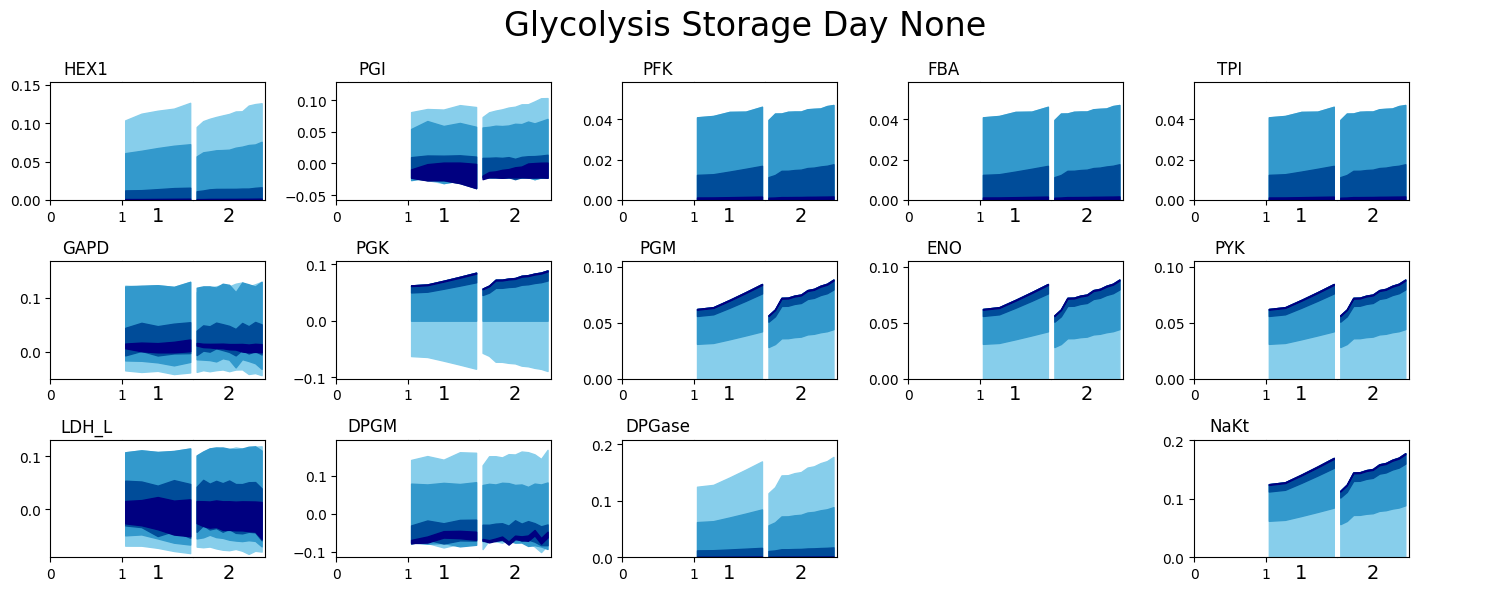

In [133]:
flux_group_glycolysis_positions_10 = make_flux_alleles_positions_for_day(
    10, flux_group_glycolysis
)
alleles_day_flux_small_multiples(
    flux_group_glycolysis_positions_10, "Glycolysis", figsize=(15, 6)
)

[[0, 10, 'G6PDH2'], [1, 10, 'G6PDH2'], [2, 10, 'G6PDH2']]
[[0, 10, 'PGL'], [1, 10, 'PGL'], [2, 10, 'PGL']]
[[0, 10, 'GND'], [1, 10, 'GND'], [2, 10, 'GND']]
[[0, 10, 'RPE'], [1, 10, 'RPE'], [2, 10, 'RPE']]
[[0, 10, 'RPI'], [1, 10, 'RPI'], [2, 10, 'RPI']]
[[0, 10, 'TKT1'], [1, 10, 'TKT1'], [2, 10, 'TKT1']]
[[0, 10, 'TALA'], [1, 10, 'TALA'], [2, 10, 'TALA']]
[[0, 10, 'TKT2'], [1, 10, 'TKT2'], [2, 10, 'TKT2']]
[[0, 10, 'PRPPS'], [1, 10, 'PRPPS'], [2, 10, 'PRPPS']]
[[0, 10, 'NaKt'], [1, 10, 'NaKt'], [2, 10, 'NaKt']]


C:\Users\Alicia Key\AppData\Local\Temp\ipykernel_29512\1444238643.py:63: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  fig.tight_layout()


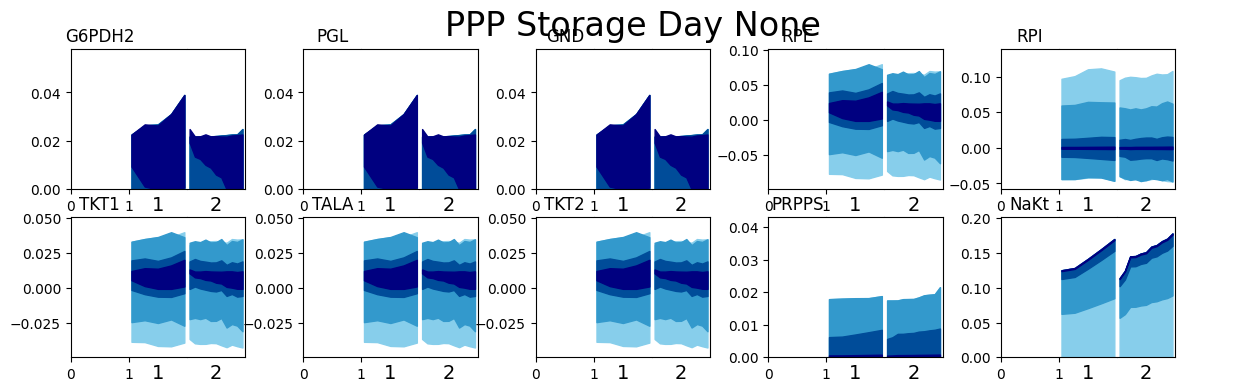

In [134]:
flux_group_ppp_positions_10 = make_flux_alleles_positions_for_day(10, flux_group_ppp)
alleles_day_flux_small_multiples(flux_group_ppp_positions_10, "PPP", figsize=(15, 4))

[[0, 10, 'ADPT'], [1, 10, 'ADPT'], [2, 10, 'ADPT']]
[[0, 10, 'ADK1'], [1, 10, 'ADK1'], [2, 10, 'ADK1']]
[[0, 10, 'ADNK1'], [1, 10, 'ADNK1'], [2, 10, 'ADNK1']]
[[0, 10, 'ADA'], [1, 10, 'ADA'], [2, 10, 'ADA']]
[[0, 10, 'AMPDA'], [1, 10, 'AMPDA'], [2, 10, 'AMPDA']]
[[0, 10, 'NTDIMP'], [1, 10, 'NTDIMP'], [2, 10, 'NTDIMP']]
[[0, 10, 'NTDAMP'], [1, 10, 'NTDAMP'], [2, 10, 'NTDAMP']]
[[0, 10, 'PUNP5'], [1, 10, 'PUNP5'], [2, 10, 'PUNP5']]
[[0, 10, 'HXPRT'], [1, 10, 'HXPRT'], [2, 10, 'HXPRT']]
[[0, 10, 'NaKt'], [1, 10, 'NaKt'], [2, 10, 'NaKt']]


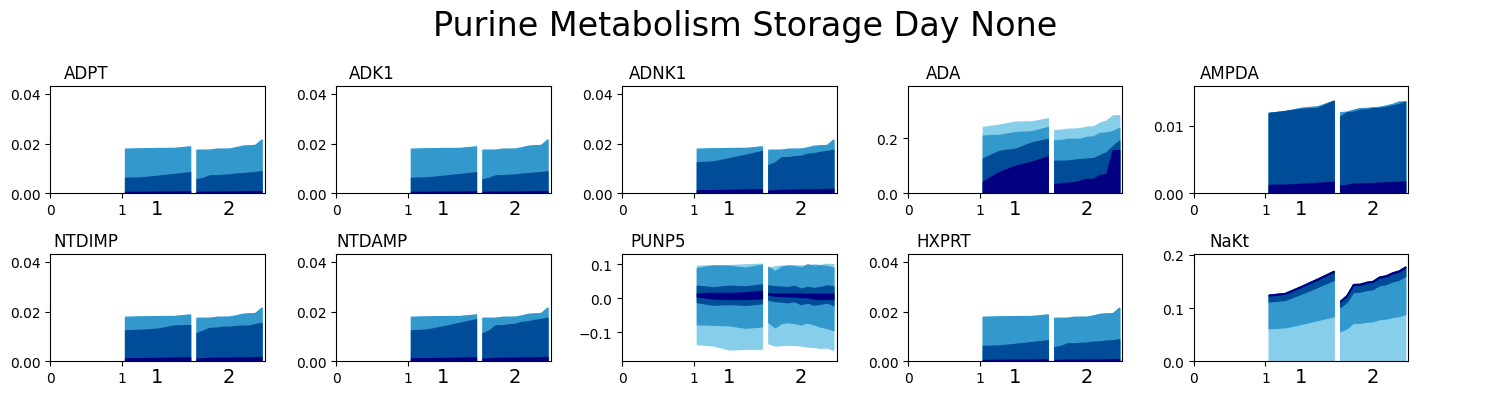

In [135]:
flux_group_purine_metabolism_positions_10 = make_flux_alleles_positions_for_day(
    10, flux_group_purine_metabolism
)
alleles_day_flux_small_multiples(
    flux_group_purine_metabolism_positions_10, "Purine Metabolism", figsize=(15, 4)
)